For a given case, explore the predicition processes for our method

case : MR_BraTS-T2f_bratsgli_0029.npz 

In [1]:
%load_ext autoreload
%autoreload 2

from src.config import config
import pandas as pd
import os
img_dir = os.path.join(config["DATA_DIR"], "3D_val_npz")
gts_dir = os.path.join(config["DATA_DIR"], "3D_val_gt_interactive_seg")
output_dir = os.path.join(config["RESULTS_DIR"], "postchallenge_20250728_121437")
final_metrics = ['DSC_AUC', 'NSD_AUC', 'DSC_Final', 'NSD_Final', 'TotalRunningTime']

Loaded configuration for machine: nora


In [2]:
nninteractivemetrics_df = pd.read_csv(os.path.join(config["RESULTS_DIR"], "nninteractive_metrics_combined.csv"))
evalmetrics_df = pd.read_csv(os.path.join(output_dir, "norateam_metrics.csv"))
# worst 10 cases in evalmetrics_df
worst_cases = evalmetrics_df.sort_values(by="DSC_Final").head(10)
print("Worst 10 cases in evalmetrics_df:")
worst_cases[["CaseName",] + final_metrics]

Worst 10 cases in evalmetrics_df:


,CaseName,DSC_AUC,NSD_AUC,DSC_Final,NSD_Final,TotalRunningTime
230,MR_BraTS-T1c_bratsgli_0739,0.022183,0.000000,0.006146,0.0,3.778323
827,MR_heart-ACDC_ACDC_patient061_frame01_myo,0.020658,0.000000,0.006584,0.0,2.789367
443,MR_BraTS-T2f_bratsgli_0108,0.410777,0.182042,0.012134,0.0,5.492416
890,MR_heart-ACDC_ACDC_patient070_frame01_myo,0.089164,0.000000,0.013844,0.0,2.946211
233,MR_BraTS-T1n_bratsgli_1024,0.037864,0.000000,0.014349,0.0,1.853037
857,MR_BraTS-T1n_bratsgli_0450,0.061298,0.000000,0.014499,0.0,4.674710
806,MR_BraTS-T2f_bratsgli_1297,0.045872,0.000000,0.016379,0.0,5.645693
826,MR_BraTS-T1c_bratsgli_1024,0.048522,0.000000,0.021426,0.0,1.934277
914,MR_BraTS-T1c_bratsgli_0449,0.074859,0.000000,0.025451,0.0,4.242375
261,MR_BraTS-T2f_bratsgli_1049,0.516734,0.224451,0.025925,0.0,8.166480


In [34]:

case_filename = "MR_heart-ACDC_ACDC_patient070_frame01_myo"
print(f"Metrics for case {case_filename} in nninteractive_metrics_combined.csv:")
print(nninteractivemetrics_df[nninteractivemetrics_df["CaseName"].str.contains(case_filename)][final_metrics])
print(f"Metrics for case {case_filename} in norateam_metrics.csv:")
print(evalmetrics_df[evalmetrics_df["CaseName"].str.contains(case_filename)][final_metrics])

Metrics for case MR_heart-ACDC_ACDC_patient070_frame01_myo in nninteractive_metrics_combined.csv:
      DSC_AUC   NSD_AUC  DSC_Final  NSD_Final  TotalRunningTime
500  3.024134  3.583164   0.750412   0.886598         38.261509
Metrics for case MR_heart-ACDC_ACDC_patient070_frame01_myo in norateam_metrics.csv:
      DSC_AUC  NSD_AUC  DSC_Final  NSD_Final  TotalRunningTime
890  0.089164      0.0   0.013844        0.0          2.946211


classes in ground truth: [0 1]


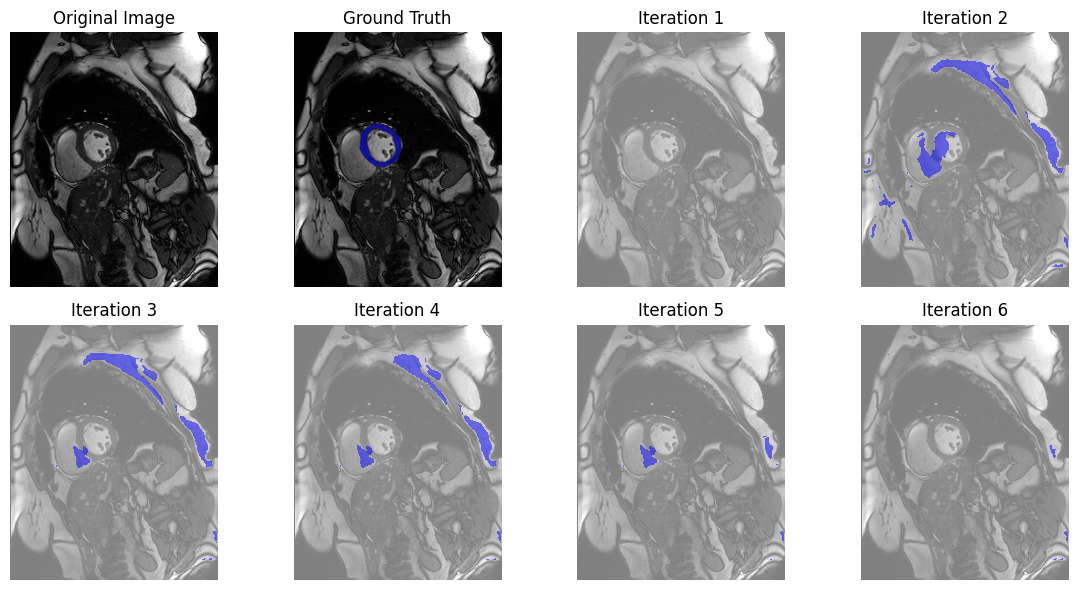

In [35]:
from medical_imagery_journals.helper_functions import display_evolution
output_dir = os.path.join(config["RESULTS_DIR"], "postchallenge_20250728_121437")

display_evolution(case_filename, img_dir, gts_dir, output_dir, class_id=1)


gt shape: (22, 218, 182)
Bounding box : {'z_min': 0, 'z_max': 21, 'z_mid': 11, 'z_mid_x_min': 24, 'z_mid_y_min': 29, 'z_mid_x_max': 151, 'z_mid_y_max': 143}


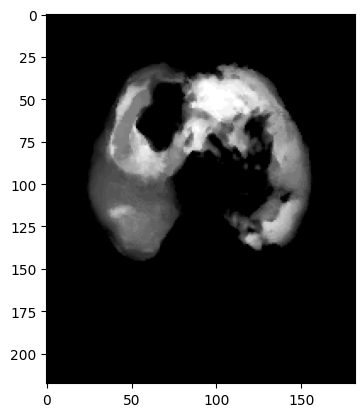

In [33]:
# localize the gt seg in the image
import numpy as np
gt = np.load(os.path.join(output_dir, case_filename + ".npz"))["segs"]
class_id = 1
from src.training.transforms import mask3D_to_bbox
bbox = mask3D_to_bbox(gt == class_id)
print(f"gt shape: {gt.shape}")
print(f"Bounding box : {bbox}")

import matplotlib.pyplot as plt
plt.imshow(gt.mean(axis=0), cmap="gray")


Vizualize the steps of the prediction process.


In [3]:

import sys
# append current directory to sys.path
sys.path.append("/nfs/norasys/notebooks/camaret/segfm3d_nora_team/experiments/post_challenge")
from postchallenge_method import SimplePredictor

In [4]:

trained_checkpoint_path = "/nfs/data/nii/data1/Analysis/GPUnet/ANALYSIS_incontext/SegFM3D/results/postchallengemodel_20250727_233357/fold_0/checkpoint_final.pth"

predictor = SimplePredictor(trained_checkpoint_path, device="cuda", include_previous_clicks=True, n_pred_iters=1)

Loading /nfs/data/nii/data1/Analysis/GPUnet/ANALYSIS_incontext/SegFM3D/results/postchallengemodel_20250727_233357/fold_0/checkpoint_final.pth
Using 1 predictions ...


In [5]:
import numpy as np
import os
from src.eval_metrics import (  # TODO : Use the competition repo as source instead
    compute_edt,
    compute_multi_class_dsc,
    compute_multi_class_nsd,
    sample_coord,
)
import matplotlib.pyplot as plt
from utils import draw_pred_contours, generate_clicks

#case_filename = "MR_Head_HNTSMRG24_195_midRT_T2" # good
case_filename = "MR_BraTS-T2f_bratsgli_0108" # poor
input_filepath = os.path.join(img_dir, case_filename + ".npz")
gt_filepath = os.path.join(gts_dir, case_filename + ".npz")
data = np.load(input_filepath, allow_pickle=True)
gt_data = np.load(gt_filepath)

image = data["imgs"]
spacing = data["spacing"]
gts = gt_data["gts"]
boxes = data.get("boxes", None)
unique_gts = np.sort(np.unique(gts))
n_classes = len(unique_gts) - 1  # Exclude background class 0
clicks_cls = [
                {"fg": [], "bg": []} for _ in range(n_classes)
            ]  # skip background class 0
clicks_order = [[] for _ in range(n_classes)]
segs = np.zeros_like(gts, dtype=np.uint8)

In [16]:
segs, prediction_metrics = predictor.predict(
                    image=image,
                    bboxs=boxes,
                    clicks=(clicks_cls, clicks_order),
                    prev_pred=segs,  # Pass previous prediction
                )
generate_clicks(gts, segs, clicks_cls, clicks_order)
print(image.shape, segs.shape, gts.shape)
print("GT count : ", np.unique(gts, return_counts=True))
print("pred count: ", np.unique(segs,return_counts=True))
dsc = compute_multi_class_dsc(gts, segs)
print(f"DSC: {dsc}")

Finished predicting in 1.1, 0.024 in forward and rescale (2.1%), 0.12 in cropping with bbox (10.6%)
(81, 218, 182) (81, 218, 182) (81, 218, 182)
GT count :  (array([0, 1, 2, 3], dtype=uint8), array([3156185,   55819,     935,     817]))
pred count:  (array([0, 1, 2, 3]), array([3177901,   34418,    1081,     356]))
DSC: 0.47111745092537616


Click coordinates for class 1: {'fg': [[46, 74, 129], [60, 75, 116], [50, 104, 123], [68, 85, 124], [29, 60, 123], [55, 117, 111]], 'bg': []}
Click coordinates for class 2: {'fg': [[55, 81, 129], [65, 74, 127], [65, 74, 132], [57, 81, 131]], 'bg': [[54, 92, 129], [58, 126, 123]]}
Click coordinates for class 3: {'fg': [[63, 82, 133], [70, 77, 127], [59, 90, 133], [58, 86, 132], [59, 84, 131]], 'bg': [[67, 82, 129]]}


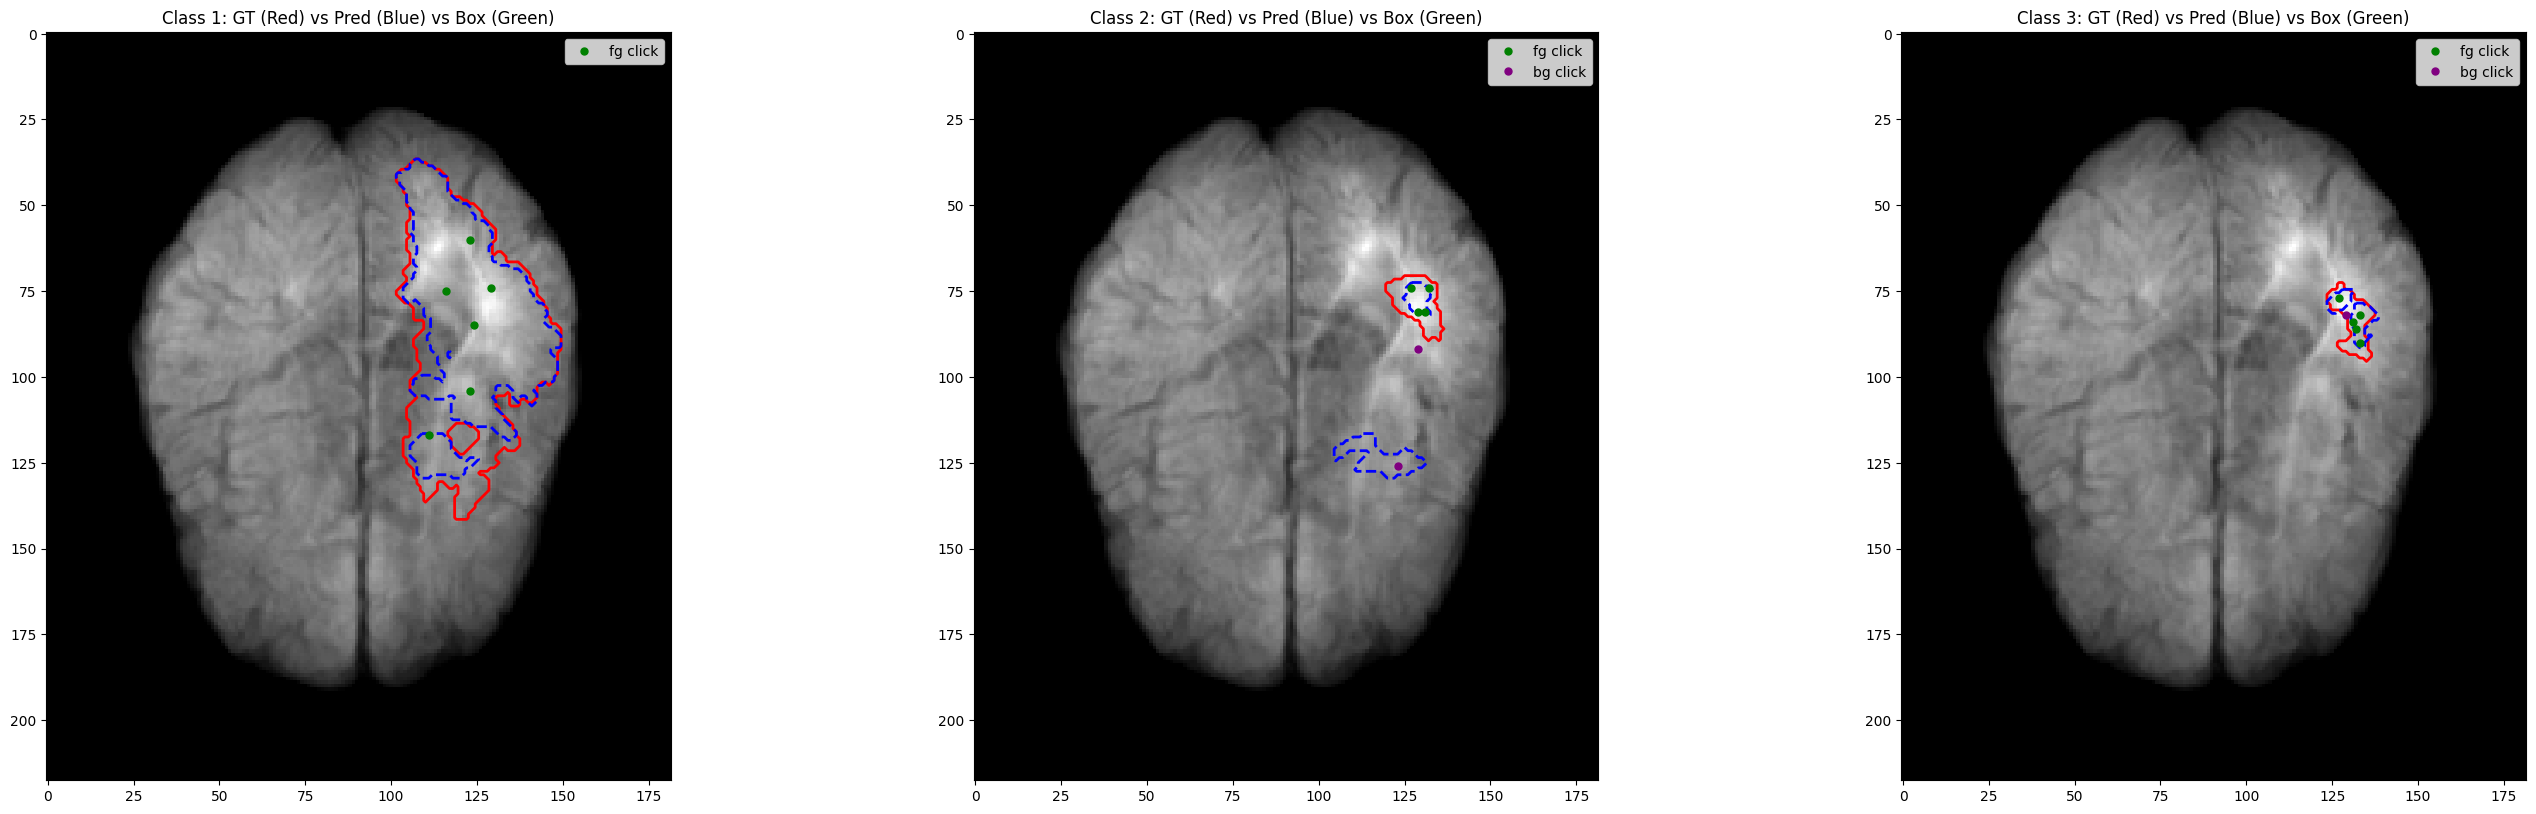

[{'fg': [[46, 74, 129], [60, 75, 116], [50, 104, 123], [68, 85, 124], [29, 60, 123], [55, 117, 111]], 'bg': []}, {'fg': [[55, 81, 129], [65, 74, 127], [65, 74, 132], [57, 81, 131]], 'bg': [[54, 92, 129], [58, 126, 123]]}, {'fg': [[63, 82, 133], [70, 77, 127], [59, 90, 133], [58, 86, 132], [59, 84, 131]], 'bg': [[67, 82, 129]]}] [['fg', 'fg', 'fg', 'fg', 'fg', 'fg'], ['fg', 'bg', 'fg', 'fg', 'fg', 'bg'], ['fg', 'bg', 'fg', 'fg', 'fg', 'fg']]


In [17]:
class_idx_list = np.unique(gts)[1:]  # Exclude background class 0
draw_pred_contours(image, gts, segs, boxes, class_idx_list=class_idx_list, clicks_cls=clicks_cls)
print(clicks_cls, clicks_order)